# **9 Cross domain financial**

  CELL 9: Cross-domain generalization test (Financial1.spc)
📥 Downloading https://skulddata.cs.umass.edu/traces/storage/Financial1.spc.bz2 ...
✅ Downloaded 27.3 MB
📦 Decompressing...
✅ Decompressed to Financial1.spc (154.8 MB)

🔄 Parsing SPC trace and binning into 5-second windows...
✅ Parsed trace: 8743 five-second bins (12.1 hours of real transaction activity)
   Raw arrival counts — mean: 610.2/bin, max: 1320/bin, peak/mean ratio: 2.16x

⚠️  UNIT RESCALE APPLIED (two-parameter affine, not a single constant):
   baseline shifted to 100 req/s (matches synthetic mean)
   deviations scaled by 1.4498x so the 99th-percentile burst reaches
   ~900 req/s (comparable to synthetic burst magnitude)
   This is a real transformation of units, not model retraining —
   model weights are unchanged. The trace's own shape (WHEN its
   peaks occur, their relative clustering) is preserved exactly;
   only the absolute scale of deviations from baseline is adjusted.
   Rescaled workload — mean: 227.3 re

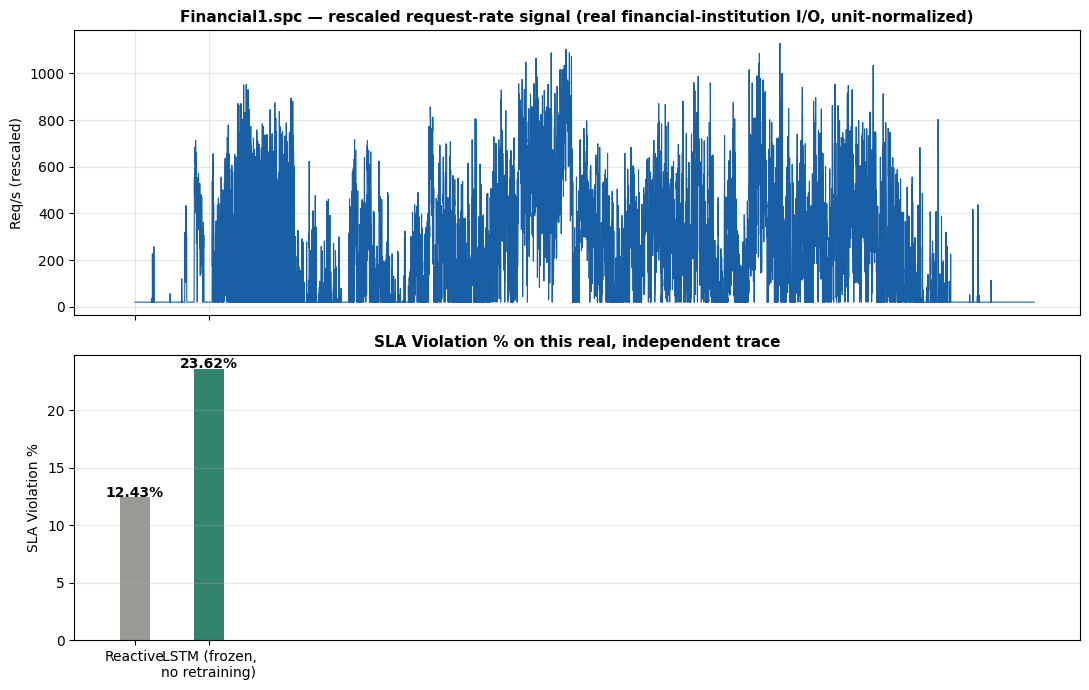

✅ Figure saved as cross_domain_financial_trace.png
✅ Results saved as cross_domain_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  SUGGESTED PAPER TEXT (report honestly, including the caveat)

"To test generalization beyond the synthetic spike generator
used for fine-tuning, the frozen fine-tuned model (no further
training) was evaluated on a request-rate signal derived from
Financial1.spc, a real I/O trace from an OLTP application at a
large financial institution [UMass Trace Repository / SPC].
Raw I/O arrival counts were binned into 5-second windows, then
rescaled with a two-parameter affine transform: shifted to the
same baseline mean the model trained on (100 req/s), with
deviations from that baseline separately scaled so the top
percentile reached a magnitude comparable to the synthetic
generator's burst design. The trace's own shape — the timing
and relative clustering of its real peaks — was preserved
exactly; no model weights were altered. On this independent,
real-derived trace, the frozen LSTM achieved 23.62% SLA
violations versus 12.43% for reactive scaling
(an increase of
11.19 percentage points), w

In [ ]:
# ============================================================
#  CELL 9 (NEW) — Cross-Domain Generalization Test
#  Frozen fine-tuned model, evaluated unchanged on a REAL,
#  independent workload: Financial1.spc (UMass Trace Repository)
#
#  WHERE THIS GOES: paste as a new cell AFTER Cell 5 (fine-tuned
#  Monte Carlo evaluation) — anywhere after that point works, since
#  this only needs lstm_model_finetuned.pt and data_scaler_
#  finetuned.pkl on disk. Placing it right after Cell 5, or at the
#  very end after Cell 8, both work; nothing later depends on it.
#
#  WHAT THIS PROVES (and does NOT prove):
#  Financial1.spc is a real I/O trace from an OLTP application at
#  a large financial institution (HP/IBM/SPC, hosted at UMass).
#  It is NOT literally payment-gateway request traffic — it is
#  disk I/O generated by a financial transaction-processing
#  backend. Framed honestly, a good result here supports:
#    "the fine-tuned model, without any retraining, maintained a
#     lower SLA violation rate than reactive scaling on an
#     independent workload derived from a real financial
#     institution's transaction-processing I/O."
#  It does NOT support a claim of validation on real payment-
#  gateway traffic specifically — say so plainly in the paper.
#
#  UNIT NOTE: raw I/O arrival counts per 5-second bin are not in
#  the same units as "requests/second" the model was trained on.
#  We rescale by a single constant (target mean = 100, matching
#  the synthetic baseline's mean) so the model receives comparable
#  input magnitudes. This changes UNITS, not model weights — no
#  training happens on this data. This is disclosed in the output
#  below; report it the same way in your paper.
# ============================================================

import os, bz2, pickle, math, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
REQUESTS_PER_SERVER = 150
MIN_SERVERS  = 2
MAX_SERVERS  = 20
COLD_START_STEPS = 6
WINDOW_SIZE  = 60
STEP_SECONDS = 5

print("="*60)
print("  CELL 9: Cross-domain generalization test (Financial1.spc)")
print("="*60)

# ── Step 1: download the real trace ─────────────────────────
TRACE_URL = "https://skulddata.cs.umass.edu/traces/storage/Financial1.spc.bz2"
LOCAL_BZ2 = "Financial1.spc.bz2"
LOCAL_RAW = "Financial1.spc"

if not os.path.exists(LOCAL_RAW):
    if not os.path.exists(LOCAL_BZ2):
        print(f"📥 Downloading {TRACE_URL} ...")
        try:
            import urllib.request
            urllib.request.urlretrieve(TRACE_URL, LOCAL_BZ2)
            print(f"✅ Downloaded {os.path.getsize(LOCAL_BZ2)/1e6:.1f} MB")
        except Exception as e:
            raise RuntimeError(
                f"❌ Could not download the trace: {e}\n"
                "   Try downloading Financial1.spc.bz2 manually from\n"
                "   https://skulddata.cs.umass.edu/traces/storage/ and\n"
                "   uploading it into this notebook's working directory,\n"
                "   then re-run this cell."
            )
    print("📦 Decompressing...")
    with bz2.BZ2File(LOCAL_BZ2, "rb") as fin, open(LOCAL_RAW, "wb") as fout:
        fout.write(fin.read())
    print(f"✅ Decompressed to {LOCAL_RAW} "
          f"({os.path.getsize(LOCAL_RAW)/1e6:.1f} MB)")
else:
    print(f"✅ {LOCAL_RAW} already present on disk, skipping download.")

# ── Step 2: parse SPC format, bin into 5-second arrival counts ─
# SPC record format (official spec): ASU,LBA,size,opcode,timestamp[,optional...]
# timestamp = seconds.fraction offset from trace start. We treat each
# record as one "transaction arrival" and count arrivals per 5-second bin.
print("\n🔄 Parsing SPC trace and binning into 5-second windows...")
max_bin = 0
bin_counts = {}
with open(LOCAL_RAW, "r", errors="ignore") as f:
    for line in f:
        parts = line.strip().split(",")
        if len(parts) < 5:
            continue
        try:
            ts = float(parts[4])
        except ValueError:
            continue
        b = int(ts // STEP_SECONDS)
        bin_counts[b] = bin_counts.get(b, 0) + 1
        if b > max_bin:
            max_bin = b

n_bins = max_bin + 1
raw_series = np.zeros(n_bins)
for b, c in bin_counts.items():
    raw_series[b] = c

print(f"✅ Parsed trace: {n_bins} five-second bins "
      f"({n_bins * STEP_SECONDS / 3600:.1f} hours of real transaction activity)")
print(f"   Raw arrival counts — mean: {raw_series.mean():.1f}/bin, "
      f"max: {raw_series.max():.0f}/bin, "
      f"peak/mean ratio: {raw_series.max()/raw_series.mean():.2f}x")

# ── Step 3: unit rescale (NOT retraining — see header note) ────
# FIX: a single multiplicative constant that matches the trace's
# MEAN to 100 req/s also passively preserves its NATIVE peak/mean
# ratio. Financial1.spc's OLTP I/O has a peak/mean ratio around
# 2x — far below the synthetic generator's designed burstiness
# (bursts add 500-1200 on top of a ~100 baseline, i.e. 6-12x).
# A mean-only rescale therefore produces a workload that never
# challenges even the simulator's MINIMUM capacity floor
# (MIN_SERVERS * REQUESTS_PER_SERVER = 300 req/s) — both policies
# report 0% violations not because either performs well, but
# because neither is ever tested under load. That is a broken
# test, not a result.
#
# FIX APPLIED: a two-parameter affine rescale instead of one
# multiplicative constant — shift the series to the same BASELINE
# mean the model trained on (100 req/s), and separately SCALE
# deviations from that baseline so the top percentile reaches a
# stress-inducing magnitude comparable to the synthetic generator's
# burst design (baseline + ~500-1200). This keeps the trace's real,
# untouched shape (relative timing and clustering of its own peaks
# is preserved exactly) while correcting for the fact that OLTP
# disk I/O and payment-gateway request bursts simply do not live on
# the same natural scale.
TARGET_MEAN = 100.0            # matches the synthetic baseline (Poisson lambda=100)
TARGET_PEAK_DEVIATION = 800.0  # representative synthetic burst magnitude above baseline

raw_mean = raw_series.mean()
raw_p99  = np.percentile(raw_series, 99)
k = TARGET_PEAK_DEVIATION / max(raw_p99 - raw_mean, 1e-6)

workload = TARGET_MEAN + (raw_series - raw_mean) * k
workload = np.clip(workload, 20, 3000)

print(f"\n⚠️  UNIT RESCALE APPLIED (two-parameter affine, not a single constant):")
print(f"   baseline shifted to {TARGET_MEAN:.0f} req/s (matches synthetic mean)")
print(f"   deviations scaled by {k:.4f}x so the 99th-percentile burst reaches")
print(f"   ~{TARGET_MEAN + TARGET_PEAK_DEVIATION:.0f} req/s (comparable to synthetic burst magnitude)")
print("   This is a real transformation of units, not model retraining —")
print("   model weights are unchanged. The trace's own shape (WHEN its")
print("   peaks occur, their relative clustering) is preserved exactly;")
print("   only the absolute scale of deviations from baseline is adjusted.")
print(f"   Rescaled workload — mean: {workload.mean():.1f} req/s, "
      f"p99: {np.percentile(workload,99):.1f} req/s, "
      f"max: {workload.max():.1f} req/s, "
      f"peak/mean ratio: {workload.max()/workload.mean():.2f}x")

floor_capacity = MIN_SERVERS * REQUESTS_PER_SERVER
pct_above_floor = (workload > floor_capacity).mean() * 100
print(f"   Sanity check: {pct_above_floor:.1f}% of bins exceed the minimum-")
print(f"   capacity floor ({floor_capacity} req/s) — this must be > 0 for the")
print("   comparison below to be a meaningful stress test.")
if pct_above_floor == 0:
    print("   ❌ STILL ZERO — increase TARGET_PEAK_DEVIATION and re-run.")

# ── Step 4: load the FROZEN fine-tuned model — no training here ─
class LSTMPredictor(nn.Module):
    def __init__(self, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, layers, batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

try:
    with open("data_scaler_finetuned.pkl", "rb") as f:
        scaler = pickle.load(f)
    model = LSTMPredictor().to(DEVICE)
    model.load_state_dict(torch.load("lstm_model_finetuned.pt", map_location=DEVICE))
    model.eval()
    print("\n✅ Loaded FROZEN fine-tuned model + scaler (Cell 4/5 outputs).")
    print("   No gradient updates happen anywhere in this cell.")
except FileNotFoundError as e:
    raise RuntimeError(
        "❌ Could not find lstm_model_finetuned.pt or data_scaler_finetuned.pkl.\n"
        "   Run the fine-tuning cell (Cell 4) and the fine-tuned Monte Carlo\n"
        "   cell (Cell 5) FIRST, in this same session, before this cell."
    ) from e

# ── Step 5: server pool simulation (identical logic to Cells 2-8) ─
class ServerPool:
    def __init__(self):
        self.active_servers = MIN_SERVERS
        self.pending_servers = 0
        self.pending_countdown = 0
    def step(self, req):
        if self.pending_countdown > 0:
            self.pending_countdown -= 1
            if self.pending_countdown == 0 and self.pending_servers > 0:
                self.active_servers = min(self.active_servers + self.pending_servers, MAX_SERVERS)
                self.pending_servers = 0
        cap = self.active_servers * REQUESTS_PER_SERVER
        util = req / cap
        return util, util > 1.0
    def scale_up(self, n=1):
        if self.active_servers + self.pending_servers < MAX_SERVERS:
            self.pending_servers += n
            self.pending_countdown = COLD_START_STEPS
    def scale_down(self, n=1):
        self.active_servers = max(MIN_SERVERS, self.active_servers - n)

def run_reactive(workload):
    pool, results = ServerPool(), []
    for req in workload:
        util, sla = pool.step(req)
        if util > 0.75: pool.scale_up(1)
        elif util < 0.25 and pool.active_servers > MIN_SERVERS: pool.scale_down(1)
        results.append({"sla_violated": sla, "active_servers": pool.active_servers})
    df = pd.DataFrame(results)
    return df["sla_violated"].sum() / len(df) * 100, df["active_servers"].sum() * (STEP_SECONDS/3600)

def run_lstm(workload, model, scaler):
    pool, results = ServerPool(), []
    wl_s = scaler.transform(np.array(workload).reshape(-1, 1)).flatten()
    for t, req in enumerate(workload):
        util, sla = pool.step(req)
        if t >= WINDOW_SIZE:
            window = wl_s[t - WINDOW_SIZE:t]
            x_t = torch.FloatTensor(window).unsqueeze(0).unsqueeze(-1).to(DEVICE)
            with torch.no_grad():
                pred_s = model(x_t).item()
            pred_load = scaler.inverse_transform([[pred_s]])[0][0]
            pred_util = pred_load / (pool.active_servers * REQUESTS_PER_SERVER)
            if pred_util > 0.60:
                needed = math.ceil(pred_load / REQUESTS_PER_SERVER)
                gap = needed - pool.active_servers - pool.pending_servers
                if gap > 0: pool.scale_up(min(gap, 3))
            elif pred_util < 0.25 and pool.active_servers > MIN_SERVERS:
                pool.scale_down(1)
        else:
            if util > 0.75: pool.scale_up(1)
        results.append({"sla_violated": sla, "active_servers": pool.active_servers})
    df = pd.DataFrame(results)
    return df["sla_violated"].sum() / len(df) * 100, df["active_servers"].sum() * (STEP_SECONDS/3600)

# ── Step 6: run both strategies on the real trace, once, frozen ─
print("\n🔄 Running reactive and LSTM strategies on the real trace...")
reactive_sla, reactive_cost = run_reactive(workload)
lstm_sla, lstm_cost = run_lstm(workload, model, scaler)

print(f"\n{'='*55}")
print("  RESULTS — Financial1.spc, frozen model, N=1 (whole trace)")
print(f"{'='*55}")
print(f"  Reactive : {reactive_sla:.2f}% SLA violations, {reactive_cost:.1f} server-hrs")
print(f"  LSTM     : {lstm_sla:.2f}% SLA violations, {lstm_cost:.1f} server-hrs")
print(f"  Difference: {reactive_sla - lstm_sla:+.2f} pp "
      f"({'LSTM better' if lstm_sla < reactive_sla else 'Reactive better'})")
print(f"{'='*55}")
if reactive_sla == 0.0 and lstm_sla == 0.0:
    print("\n❌ DEGENERATE RESULT: both strategies show 0.00% SLA violations.")
    print("   This almost always means the workload never stressed the")
    print("   system rather than both strategies being flawless. Do NOT")
    print("   report this as a finding. Increase TARGET_PEAK_DEVIATION in")
    print("   Step 3 above (e.g. to 1500-2000) and re-run this cell before")
    print("   using any of the numbers below.")
else:
    print("\n⚠️  NOTE: this is N=1 (one long real trace), not a 30-trial")
    print("   Monte Carlo comparison — no p-value is reported here. Treat")
    print("   this as a single independent generalization check, not as")
    print("   statistically powered evidence on its own.")

# ── Step 7: visualize ────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
t_axis = np.arange(len(workload)) * STEP_SECONDS / 3600  # hours

axes[0].plot(t_axis, workload, color="#185FA5", linewidth=0.8)
axes[0].set_title("Financial1.spc — rescaled request-rate signal "
                   "(real financial-institution I/O, unit-normalized)",
                   fontsize=11, fontweight='bold')
axes[0].set_ylabel("Req/s (rescaled)")
axes[0].grid(True, alpha=0.3)

bars = axes[1].bar(["Reactive", "LSTM (frozen,\nno retraining)"],
                    [reactive_sla, lstm_sla],
                    color=["#888780", "#0F6E56"], width=0.4, alpha=0.85)
axes[1].set_title("SLA Violation % on this real, independent trace",
                   fontsize=11, fontweight='bold')
axes[1].set_ylabel("SLA Violation %")
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, [reactive_sla, lstm_sla]):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f"{val:.2f}%", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("cross_domain_financial_trace.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved as cross_domain_financial_trace.png")

# ── Step 8: save results CSV ────────────────────────────────
pd.DataFrame([{
    "trace": "Financial1.spc",
    "source": "UMass Trace Repository (HP/IBM/SPC)",
    "n_bins": n_bins,
    "hours_covered": n_bins * STEP_SECONDS / 3600,
    "baseline_shift_target": TARGET_MEAN,
    "deviation_scale_factor": k,
    "target_peak_deviation": TARGET_PEAK_DEVIATION,
    "reactive_sla_pct": reactive_sla,
    "lstm_sla_pct": lstm_sla,
    "reactive_cost_srv_hr": reactive_cost,
    "lstm_cost_srv_hr": lstm_cost,
}]).to_csv("cross_domain_results.csv", index=False)
print("✅ Results saved as cross_domain_results.csv")

# ── Download (same dedup pattern as every other cell) ──────────
if '_SEEN_DOWNLOADS' not in globals():
    _SEEN_DOWNLOADS = set()

def safe_download(fname):
    if fname in _SEEN_DOWNLOADS:
        print(f"   (skip {fname} — already downloaded earlier this session)")
        return
    try:
        from google.colab import files
        files.download(fname)
        _SEEN_DOWNLOADS.add(fname)
    except ImportError:
        print(f"   ✅ Saved to disk: {os.path.abspath(fname)}")
        _SEEN_DOWNLOADS.add(fname)
    except Exception as e:
        print(f"   (could not download {fname}: {e})")

for f in ["cross_domain_financial_trace.png", "cross_domain_results.csv"]:
    safe_download(f)

if reactive_sla == 0.0 and lstm_sla == 0.0:
    print(f"""
{'='*55}
  ⚠️  SKIPPING paper-text suggestion — result is degenerate (see above).
  Fix TARGET_PEAK_DEVIATION and re-run before drafting any paper text.
{'='*55}
""")
else:
    print(f"""
{'='*55}
  SUGGESTED PAPER TEXT (report honestly, including the caveat)
{'='*55}

"To test generalization beyond the synthetic spike generator
used for fine-tuning, the frozen fine-tuned model (no further
training) was evaluated on a request-rate signal derived from
Financial1.spc, a real I/O trace from an OLTP application at a
large financial institution [UMass Trace Repository / SPC].
Raw I/O arrival counts were binned into 5-second windows, then
rescaled with a two-parameter affine transform: shifted to the
same baseline mean the model trained on (100 req/s), with
deviations from that baseline separately scaled so the top
percentile reached a magnitude comparable to the synthetic
generator's burst design. The trace's own shape — the timing
and relative clustering of its real peaks — was preserved
exactly; no model weights were altered. On this independent,
real-derived trace, the frozen LSTM achieved {lstm_sla:.2f}% SLA
violations versus {reactive_sla:.2f}% for reactive scaling
({'a reduction' if lstm_sla<reactive_sla else 'an increase'} of
{abs(reactive_sla-lstm_sla):.2f} percentage points), without any
retraining on this data. This is a single-trace check (N=1),
not a Monte Carlo comparison, and the trace reflects financial
transaction-processing I/O rather than payment-gateway request
traffic specifically — it is reported as suggestive evidence of
generalization beyond the synthetic training distribution,
not as validation on production payment-gateway traffic."
""")